# Initialization

In [1057]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import matplotlib.pyplot as plt
import time
import numpy as np

LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1069]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()
ble.reload_config()

2026-03-27 05:09:38,610 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-03-27 05:09:38,610 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600
2026-03-27 05:09:48,663 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-03-27 05:09:48,663 | INFO     |: Selecting device: 3AE32BFA-4071-EC2D-ED7A-60CCA92DBE18 (name: Artemis BLE)
2026-03-27 05:09:49,602 | INFO     |: Connected to c0:42:0c:78:b8:49


In [114]:
ble.stop_notify(ble.uuid["RX_STRING"])

In [1070]:
times = []
left_motors = []
right_motors = []
left_percent = []
right_percent = []
tof_2_values = []
sensor_values = []
acc_x_values = []


def log_handler(sender, data: bytearray):
    parts = ble.bytearray_to_string(data).split("|")
    if len(parts) == 8:
        t = float(parts[0][2:])
        lpwm = float(parts[1][5:])
        rpwm = float(parts[2][5:])
        lpec = float(parts[3][5:])
        rpec = float(parts[4][5:])
        ax = float(parts[5][3:])
        t2 = float(parts[6][3:])
        s = float(parts[7][2:])

        times.append(t) # Convert microseconds to seconds
        left_motors.append(lpwm)
        right_motors.append(rpwm)
        left_percent.append(lpec)
        right_percent.append(rpec)
        sensor_values.append(s)
        tof_2_values.append(t2)
        acc_x_values.append(ax)
        print (f"t: {t:.2f}, lm: {lpwm:.2f}, rm: {rpwm:.2f}, lp: {lpec:.2f}, rp: {rpec:.2f}, ax: {ax:.2f}, s: {s:.2f}, t2: {t2:.2f}")
    else:
        print(ble.bytearray_to_string(data))

In [1071]:
ble.start_notify(ble.uuid["RX_STRING"], log_handler)

# 1. Estimate drag and momentum

In [388]:
ble.send_command(CMD.SET_MODE, "2")
ble.send_command(CMD.SET_DURATION, "1500")
ble.send_command(CMD.SET_SETPOINT, "304")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")
ble.send_command(CMD.SET_EXTRAPOLATION, "1")
ble.send_command(CMD.SET_KALMANFILTER, "0")

In [399]:
times = []
left_motors = []
right_motors = []
left_percent = []
right_percent = []
sensor_values = []
tof_2_values = []
acc_x_values = []


ble.send_command(CMD.START_RECORD, "")
time.sleep(3)
ble.send_command(CMD.SEND_LOG, "")

t: 9.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 11.72, s: 2973.00, t2: 2973.00
t: 13.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 48.34, s: 2973.00, t2: 2973.00
t: 16.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 287.11, s: 2973.00, t2: 2973.00
t: 25.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 1124.51, s: 2973.00, t2: 2973.00
t: 28.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 242.68, s: 2973.00, t2: 2973.00
t: 34.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 675.29, s: 2973.00, t2: 2973.00
t: 38.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 533.69, s: 2973.00, t2: 2973.00
t: 46.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 269.53, s: 2973.00, t2: 2973.00
t: 49.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: -114.75, s: 2973.00, t2: 2973.00
t: 53.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 767.58, s: 2973.00, t2: 2973.00
t: 61.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax:

### Graphing

In [400]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
left_percent = np.array(left_percent)
right_percent = np.array(right_percent)
sensor_values = np.array(sensor_values)
tof_2_values = np.array(tof_2_values)
acc_x_values = np.array(acc_x_values)

In [401]:
np.savez("lab7/100pct_3m_v3.npz",
    times=times,
    left_motors=left_motors,
    right_motors=right_motors,
    left_percent=left_percent,
    right_percent=right_percent,
    tof_2_values=tof_2_values,
    sensor_values = sensor_values,
    acc_x_values=acc_x_values
)

In [426]:
data = np.load("lab7/100pct_3m_v1.npz")
times = data['times']
left_motors = data['left_motors']
right_motors = data['right_motors']
left_percent = data['left_percent']
right_percent = data['right_percent']
tof_2_values = data['tof_2_values']
sensor_values = data['sensor_values']

In [427]:
m_pct = 1.0
times = times /1000.0

In [428]:
times_v = []
velocities = []

last_tof_time = 0
last_tof_dist = tof_2_values[0] /1000.0

for i in range(0, len(times)):
    new_tof = (tof_2_values[i] != tof_2_values[i - 1])

    if new_tof:
        curr_time = times[i]
        curr_dist = tof_2_values[i] /1000.0

        if last_tof_time is not None:
            dt = curr_time - last_tof_time
            if dt > 0:
                # velocity (m/s)
                v = (last_tof_dist - curr_dist) / dt
                times_v.append(curr_time)
                velocities.append(v)

        last_tof_time = curr_time
        last_tof_dist = curr_dist

times_v = np.array(times_v)
velocities = np.array(velocities)
print ("Times (s):", times_v)
print ("Velocities (m/s):", velocities)

Times (s): [0.009 0.098 0.2   0.299 0.402 0.5   0.604 0.708 0.802 0.947 1.048 1.145
 1.252 1.352 1.448]
Velocities (m/s): [ 0.         -0.65168539  1.2745098   0.13131313  0.95145631  0.95918367
  1.73076923  2.36538462  2.91489362  2.40689655  2.86138614  2.97938144
  3.14018692  3.55        3.89583333]


In [431]:
from scipy.optimize import curve_fit
v_ss = np.mean(velocities[-4:])*1.3
def exp_rise(t, tau):
    return v_ss * (1 - np.exp(-t / tau))

params, _ = curve_fit(
    exp_rise,
    times_v,
    velocities,
    p0=[0.2],
    maxfev=20000
)

tau = params

t_fit = np.linspace(times.min(), times.max(), 500)
v_fit = exp_rise(t_fit, tau)

t_end = times.max()
v_end = exp_rise(t_end, tau)
v90 = 0.9 * v_end
idx90 = np.where(v_fit >= v90)[0][0]
t90 = t_fit[idx90]
print("vend =", v_end, "m/s, v90 =", v90, "m/s at t =", t90, "s")

vend = [3.35327544] m/s, v90 = [3.0179479] m/s at t = 1.2155771543086171 s


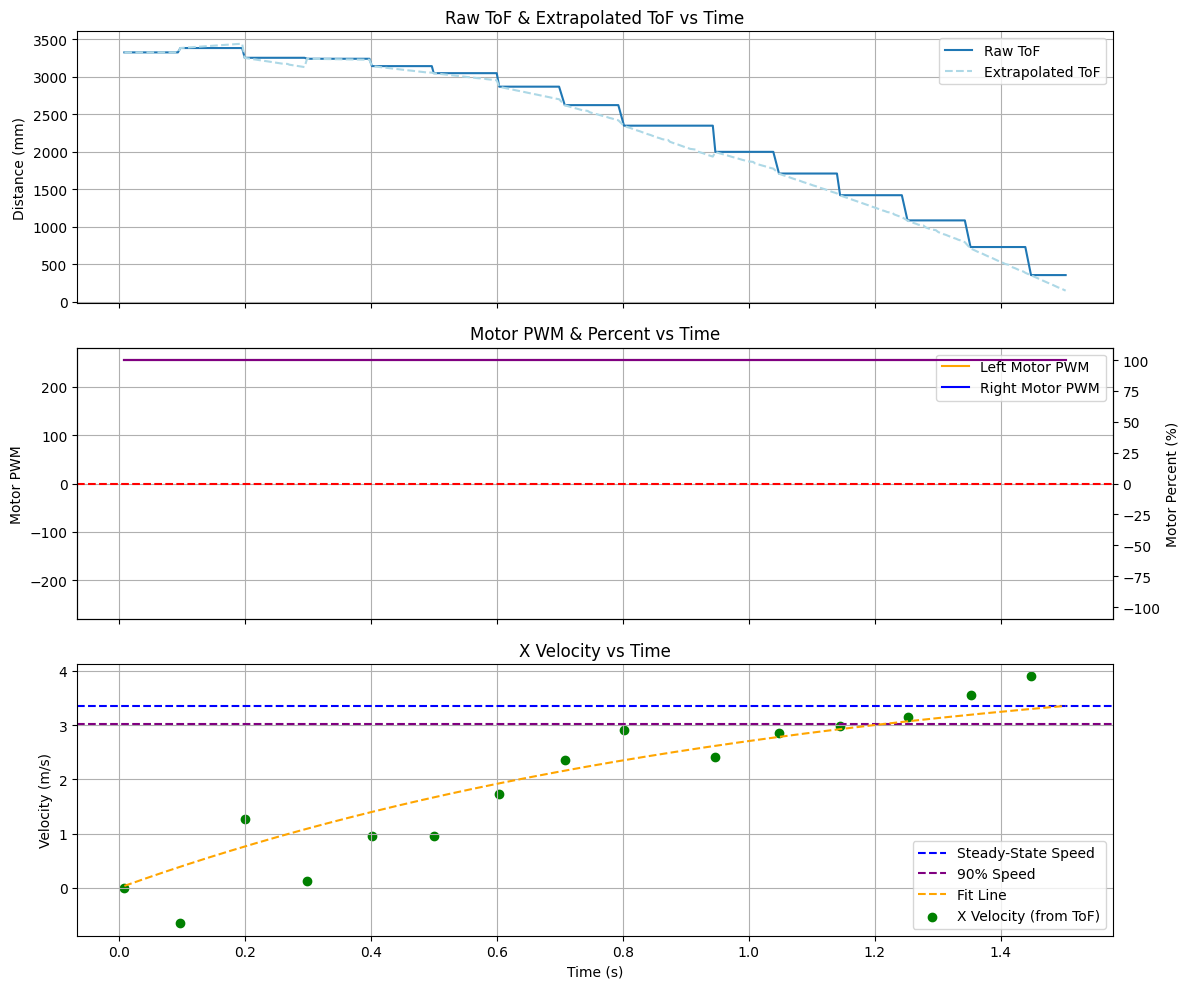

In [432]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ToF
axes[0].plot(times, tof_2_values, label='Raw ToF')
axes[0].plot(times, sensor_values, label='Extrapolated ToF', linestyle='--',  color='lightblue')
# axes[0].axhline(setpoint, linestyle='--', label='Setpoint', color='red')
axes[0].set_ylabel('Distance (mm)')
axes[0].set_title('Raw ToF & Extrapolated ToF vs Time')
axes[0].legend()
axes[0].grid(True)

# Motors
ax_pwm = axes[1]
ax_pct = ax_pwm.twinx()
ax_pwm.plot(times, left_motors, label='Left Motor PWM', color='orange')
ax_pwm.plot(times, right_motors, label='Right Motor PWM', color='blue')
ax_pwm.axhline(0, linestyle='--', color='red')
ax_pwm.set_ylabel('Motor PWM')
ax_pwm.set_title('Motor PWM & Percent vs Time')
ax_pwm.set_ylim(-280.5, 280.5)
ax_pwm.grid(True)
ax_pct.plot(times, left_percent, linestyle='-', color='purple')
ax_pct.set_ylabel('Motor Percent (%)')
ax_pct.set_ylim(-110, 110)
lines1, labels1 = ax_pwm.get_legend_handles_labels()
lines2, labels2 = ax_pct.get_legend_handles_labels()
ax_pwm.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# X velocity
axes[2].axhline(v_end, linestyle='--', color='blue', label='Steady-State Speed')
axes[2].axhline(v90, linestyle='--', color='purple', label='90% Speed')
axes[2].plot(t_fit, v_fit, label='Fit Line', linestyle='--', color='orange')
axes[2].scatter(times_v, velocities, label='X Velocity (from ToF)',  color='green')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Velocity (m/s)')
axes[2].set_title('X Velocity vs Time')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Analysis

In [433]:
steady_speed1 = v_end[0]
print(f"Estimated steady state speed: {steady_speed1:.2f} m/s")
rise_speed1 = v90[0]
print(f"Speed at 90% risetime: {rise_speed1:.2f} m/s")
rise_time1 = t90
print(f"Estimated risetime: {rise_time1:.2f} s")
      

Estimated steady state speed: 3.35 m/s
Speed at 90% risetime: 3.02 m/s
Estimated risetime: 1.22 s


In [387]:
steady_speed2 = v_end[0]
print(f"Estimated steady state speed: {steady_speed2:.2f} m/s")
rise_speed2 = v90[0]
print(f"Speed at 90% risetime: {rise_speed2:.2f} m/s")
rise_time2 = t90
print(f"Estimated risetime: {rise_time2:.2f} s")

Estimated steady state speed: 3.01 m/s
Speed at 90% risetime: 2.71 m/s
Estimated risetime: 1.05 s


In [425]:
steady_speed3 = v_end[0]
print(f"Estimated steady state speed: {steady_speed3:.2f} m/s")
rise_speed3 = v90[0]
print(f"Speed at 90% risetime: {rise_speed3:.2f} m/s")
rise_time3 = t90
print(f"Estimated risetime: {rise_time3:.2f} s")
      

Estimated steady state speed: 3.34 m/s
Speed at 90% risetime: 3.01 m/s
Estimated risetime: 1.26 s


In [1184]:
max_speed = np.mean([steady_speed1, steady_speed2, steady_speed3])
print(f"Average estimated steady state speed: {max_speed:.2f} m/s")
rise_time = np.mean([rise_time1, rise_time2, rise_time3])
print(f"Average estimated risetime: {rise_time:.2f} s")
rise_speed = np.mean([rise_speed1, rise_speed2, rise_speed3])
print(f"Average estimated risetime speed: {rise_speed:.2f} m/s")

Average estimated steady state speed: 3.24 m/s
Average estimated risetime: 1.17 s
Average estimated risetime speed: 2.91 m/s


In [ ]:
d = m_pct / (max_speed*1e3)
# d = 0.000309
m = -d * rise_time/ np.log(1 - 0.9)
# m= 0.000158
initial_tof = tof_2_values[0]
print (f"Drag coefficient d: {d:.6f}   ")
print(f"Momentum coefficient m: {m:.6f}")

Drag coefficient d: 0.000309   
Momentum coefficient m: 0.000158
Sampling time dt: 10.579281 s


# 2 . Initialize KF

In [1050]:
ble.send_command(CMD.SET_MODE, "3")
ble.send_command(CMD.SET_DURATION, "5000")

In [741]:
times = []
left_motors = []
right_motors = []
left_percent = []
right_percent = []
sensor_values = []
acc_x_values = []
tof_2_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(6)
ble.send_command(CMD.SEND_LOG, "")

t: 6.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 14.16, s: 0.00, t2: 2966.00
t: 14.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 1.95, s: 0.00, t2: 2966.00
t: 17.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 14.16, s: 0.00, t2: 2966.00
t: 25.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 4.88, s: 0.00, t2: 2966.00
t: 30.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 15.62, s: 0.00, t2: 2966.00
t: 33.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 8.30, s: 0.00, t2: 2966.00
t: 36.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 4.39, s: 0.00, t2: 2966.00
t: 40.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 0.49, s: 0.00, t2: 2966.00
t: 47.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: -1.46, s: 0.00, t2: 2966.00
t: 50.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 5.37, s: 0.00, t2: 2966.00
t: 55.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 5.37, s: 0.00, t2: 2966.00
t: 59.00, lm: 0.00, rm: 0.00, lp: 0.00, rp: 0.00, ax: 18.07, s: 0.00, t2: 2966.00
t: 62.00, lm: 0.00, rm: 

In [743]:
tof_sd= np.std(tof_2_values)
print(f"Estimated noise standard deviation: {tof_sd:.2f} mm")

Estimated noise standard deviation: 15.95 mm


In [934]:
# Measure Noise
sigma_3 = 15
print(f"Estimated noise standard deviation: {sigma_3:.2f} mm")

sigma_z = np.array([[sigma_3**2]])
sigma = np.array([[100**2, 0],[0, 100**2]]) # confidence in measurements

Estimated noise standard deviation: 15.00 mm


In [1186]:
dt = 0.0105
A = np.array([[0, 1],[0, -d/m]])
B = np.array([[0],[1/m]])
Ad = np.eye(2) + dt * A
Bd = dt * B

C = np.array([[-1, 0]])
x = np.array([[-tof_2_values[0]], [0]])
mu = np.array([[-initial_tof], [0]])
print(B)

[[   0.        ]
 [6348.45494803]]


In [954]:
# Process Noise
sigma_1 = 97.0  # Position model uncertainty
sigma_2 = 97.0  # Velocity model uncertainty
sigma_u = np.array([[sigma_1**2, 0],[0, sigma_2**2]])  # confidence in model

In [492]:
print("Ad shape:", Ad.shape)
print("Bd shape:", Bd.shape)

Ad shape: (2, 2)
Bd shape: (2, 1)


In [922]:
def kf(mu, sigma, u, y, update=True):
    mu_p = Ad.dot(mu) + Bd.dot(u)
    sigma_p = Ad.dot(sigma.dot(Ad.transpose())) + sigma_u

    if not update:
        return mu_p, sigma_p

    sigma_m = C.dot(sigma_p.dot(C.transpose())) + sigma_z
    kkf_gain = sigma_p.dot(C.transpose()).dot(np.linalg.inv(sigma_m))
    
    y_m = y - C.dot(mu_p)
    mu = mu_p + kkf_gain.dot(y_m)
    sigma = (np.eye(2) - kkf_gain.dot(C)).dot(sigma_p)
    
    return mu, sigma

# 3. Implement and Test Kalman Filter

In [494]:
ble.send_command(CMD.SET_MODE, "0")
ble.send_command(CMD.SET_DURATION, "5000")
ble.send_command(CMD.SET_SETPOINT, "304")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")
ble.send_command(CMD.UPDATE_PID, "0.05|0.0|0.03")
ble.send_command(CMD.SET_EXTRAPOLATION, "1")
ble.send_command(CMD.SET_KALMANFILTER, "0")

In [463]:
times = []
left_motors = []
right_motors = []
left_percent = []
right_percent = []
tof_2_values = []
sensor_values = []
acc_x_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(6)
ble.send_command(CMD.SEND_LOG, "")

t: 4.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 11.23, s: 2977.00, t2: 2977.00
t: 8.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 22.95, s: 2977.00, t2: 2977.00
t: 15.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: -193.36, s: 2977.00, t2: 2977.00
t: 19.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 1469.24, s: 2977.00, t2: 2977.00
t: 25.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 472.17, s: 2977.00, t2: 2977.00
t: 29.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: -23.44, s: 2977.00, t2: 2977.00
t: 33.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 1324.22, s: 2977.00, t2: 2977.00
t: 42.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 1197.75, s: 2977.00, t2: 2977.00
t: 45.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: -226.56, s: 2977.00, t2: 2977.00
t: 50.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 412.11, s: 2977.00, t2: 2977.00
t: 54.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, a

In [ ]:
np.savez("lab7/100pct_3m_raw.npz",
    times=times,
    left_motors=left_motors,
    right_motors=right_motors,
    left_percent=left_percent,
    right_percent=right_percent,
    tof_2_values=tof_2_values,
    sensor_values=sensor_values,
    acc_x_values=acc_x_values
)

In [1174]:
data = np.load("lab7/100pct_3m_raw.npz")
times = data['times']
left_motors = data['left_motors']
right_motors = data['right_motors']
left_percent = data['left_percent']
right_percent = data['right_percent']
tof_2_values = data['tof_2_values']
sensor_values = data['sensor_values']

In [753]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
left_percent = np.array(left_percent)
right_percent = np.array(right_percent)
tof_2_values = np.array(tof_2_values)
sensor_values = np.array(sensor_values)
acc_x_values = np.array(acc_x_values)

In [754]:
t_s = times/1000.0
dt = np.mean(np.diff(t_s))
print(f"Average dt: {dt:.4f} s")
u_raw = left_percent /100.0
mu = np.array([[tof_2_values[0]], [0]])

Average dt: 0.0106 s


In [931]:
tof =[]
t_tof=[]
tof_update = np.zeros_like(tof_2_values, dtype=bool)
tof_update[0]=True
last_tof_time = times[0]
last_tof_dist = tof_2_values[0]

for i in range(1, len(t_s)):
    new_tof = (tof_2_values[i] != tof_2_values[i - 1])

    if new_tof:
        tof.append(tof_2_values[i])
        t_tof.append(t_s[i])
        tof_update[i] = True

In [955]:
kf_positions = []
kf_velocities = []
last_tof_val = None

for i in range(len(t_s)):

    current_u = np.array([[u_raw[i]]])
    current_y = np.array([[tof_2_values[i]]])
        
    if tof_update[i]:
        mu, sigma = kf(mu, sigma, current_u, current_y, update=True)
    else:
        mu, sigma = kf(mu, sigma, current_u, current_y, update=False)

    kf_positions.append(mu[0, 0])
    kf_velocities.append(mu[1, 0])

kf_positions = np.array(kf_positions)
kf_velocities = np.array(kf_velocities)

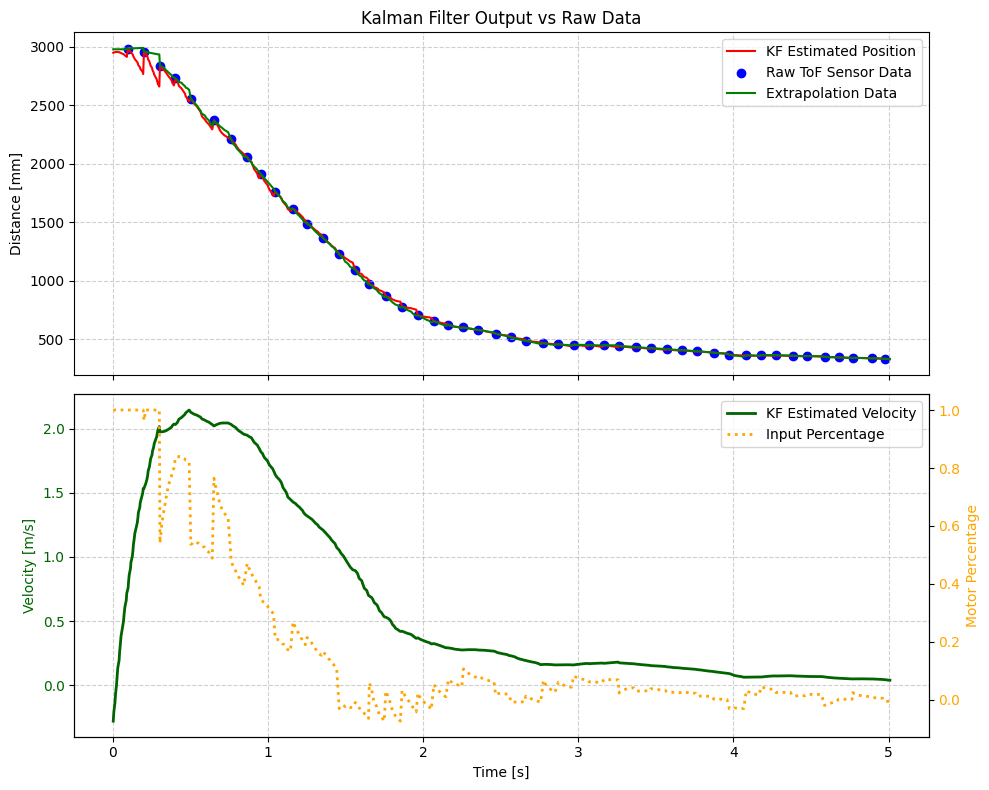

In [957]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

est_distance = [-pos for pos in kf_positions]
est_velocity = kf_velocities /1000.0
axs[0].plot(t_s, est_distance, label='KF Estimated Position', color='red')
axs[0].scatter(t_tof, tof, label='Raw ToF Sensor Data', color='blue'  )
axs[0].plot(t_s, sensor_values, label='Extrapolation Data', color='green')
axs[0].set_ylabel('Distance [mm]')
axs[0].set_title('Kalman Filter Output vs Raw Data')
# axs[0].set_xlim(1,2)

axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

color_v = 'darkgreen'
axs[1].plot(t_s, est_velocity, label='KF Estimated Velocity', color=color_v, linewidth=2)
axs[1].set_ylabel('Velocity [m/s]', color=color_v)
axs[1].tick_params(axis='y', labelcolor=color_v)
axs[1].set_xlabel('Time [s]')
axs[1].grid(True, linestyle='--', alpha=0.6)

ax2 = axs[1].twinx()
color_u = 'orange'
ax2.plot(t_s, u_raw, label='Input Percentage', color=color_u, linestyle=':', linewidth=2)
ax2.set_ylabel('Motor Percentage', color=color_u)
ax2.tick_params(axis='y', labelcolor=color_u)

lines1, labels1 = axs[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axs[1].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.tight_layout()
plt.show()

#  4. Implement the Kalman Filter on the Robot

In [1164]:
ble.send_command(CMD.SET_MODE, "0")
ble.send_command(CMD.SET_DURATION, "5000")
ble.send_command(CMD.SET_SETPOINT, "304")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")
ble.send_command(CMD.UPDATE_PID, "0.043|0|0.04")
ble.send_command(CMD.SET_KALMANFILTER, "1")

In [ ]:
times = []
left_motors = []
right_motors = []
left_percent = []
right_percent = []
sensor_values = []
tof_2_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(6)

In [1166]:
ble.send_command(CMD.SEND_LOG, "")
time.sleep(6)

t: 9.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: -8.30, s: 3058.00, t2: 3058.00
t: 13.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 30.27, s: 3058.00, t2: 3058.00
t: 17.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 631.35, s: 3058.00, t2: 3058.00
t: 26.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: -274.41, s: 3058.00, t2: 3058.00
t: 29.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 1227.05, s: 3058.00, t2: 3058.00
t: 37.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: -319.82, s: 3058.00, t2: 3058.00
t: 46.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: -102.05, s: 3058.00, t2: 3058.00
t: 49.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 852.54, s: 3058.00, t2: 3058.00
t: 57.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 503.91, s: 3058.00, t2: 3058.00
t: 66.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, ax: 745.61, s: 3058.00, t2: 3058.00
t: 69.00, lm: 255.00, rm: 255.00, lp: 100.00, rp: 100.00, a

### Graphing

In [1167]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
left_percent = np.array(left_percent)
right_percent = np.array(right_percent)
sensor_values = np.array(sensor_values)
tof_2_values = np.array(tof_2_values)

In [1173]:
np.savez("lab7/100pct_3m_car3.npz",
    times=times,
    left_motors=left_motors,
    right_motors=right_motors,
    left_percent=left_percent,
    right_percent=right_percent,
    tof_2_values=tof_2_values,
    sensor_values=sensor_values
)

In [1179]:
data = np.load("lab7/100pct_3m_car2.npz")
times = data['times']
left_motors = data['left_motors']
right_motors = data['right_motors']
left_percent = data['left_percent']
right_percent = data['right_percent']
tof_2_values = data['tof_2_values']
sensor_values = data['sensor_values']

In [1180]:
m_pct = 1.0

setpoint = 304.0
times = times /1000.0
m_ref = m_pct * 255

In [1181]:
times_v = []
velocities = []

last_tof_time = 0
last_tof_dist = tof_2_values[0] /1000.0

for i in range(0, len(times)):
    new_tof = (tof_2_values[i] != tof_2_values[i - 1])

    if new_tof:
        curr_time = times[i]
        curr_dist = tof_2_values[i] /1000.0

        if last_tof_time is not None:
            dt = curr_time - last_tof_time
            if dt > 0:
                # velocity (m/s)
                v = (last_tof_dist - curr_dist) / dt
                times_v.append(curr_time)
                velocities.append(v)

        last_tof_time = curr_time
        last_tof_dist = curr_dist

times_v = np.array(times_v)
velocities = np.array(velocities)
print ("Times (s):", times_v)
print ("Velocities (m/s):", velocities)

Times (s): [0.009 0.101 0.205 0.303 0.399 0.546 0.617 0.746 0.87  0.951 1.054 1.153
 1.267 1.358 1.454 1.561 1.668 1.76  1.862 1.97  2.06  2.16  2.267 2.358
 2.468 2.571 2.669 2.764 2.879 2.962 3.677 3.767 3.876 4.076 4.175 4.379
 4.471 4.689 4.774 4.879 4.978]
Velocities (m/s): [ 0.00000000e+00  6.52173913e-02  6.34615385e-01  7.85714286e-01
  1.48958333e+00  1.27210884e+00  2.23943662e+00  2.06976744e+00
  1.66935484e+00  2.40740741e+00  1.91262136e+00  1.86868687e+00
  1.62280702e+00  1.82417582e+00  1.62500000e+00  1.13084112e+00
  1.06542056e+00  9.67391304e-01  4.80392157e-01  8.33333333e-02
 -1.22222222e-01 -1.00000000e-01 -2.42990654e-01 -2.96703297e-01
 -9.09090909e-02 -7.76699029e-02 -7.14285714e-02 -1.05263158e-02
 -4.34782609e-02  2.40963855e-02  1.39860140e-03 -2.22222222e-02
  2.75229358e-02 -5.00000000e-03  2.02020202e-02  4.90196078e-03
 -1.08695652e-02  1.37614679e-02 -1.17647059e-02  5.71428571e-02
  7.07070707e-02]


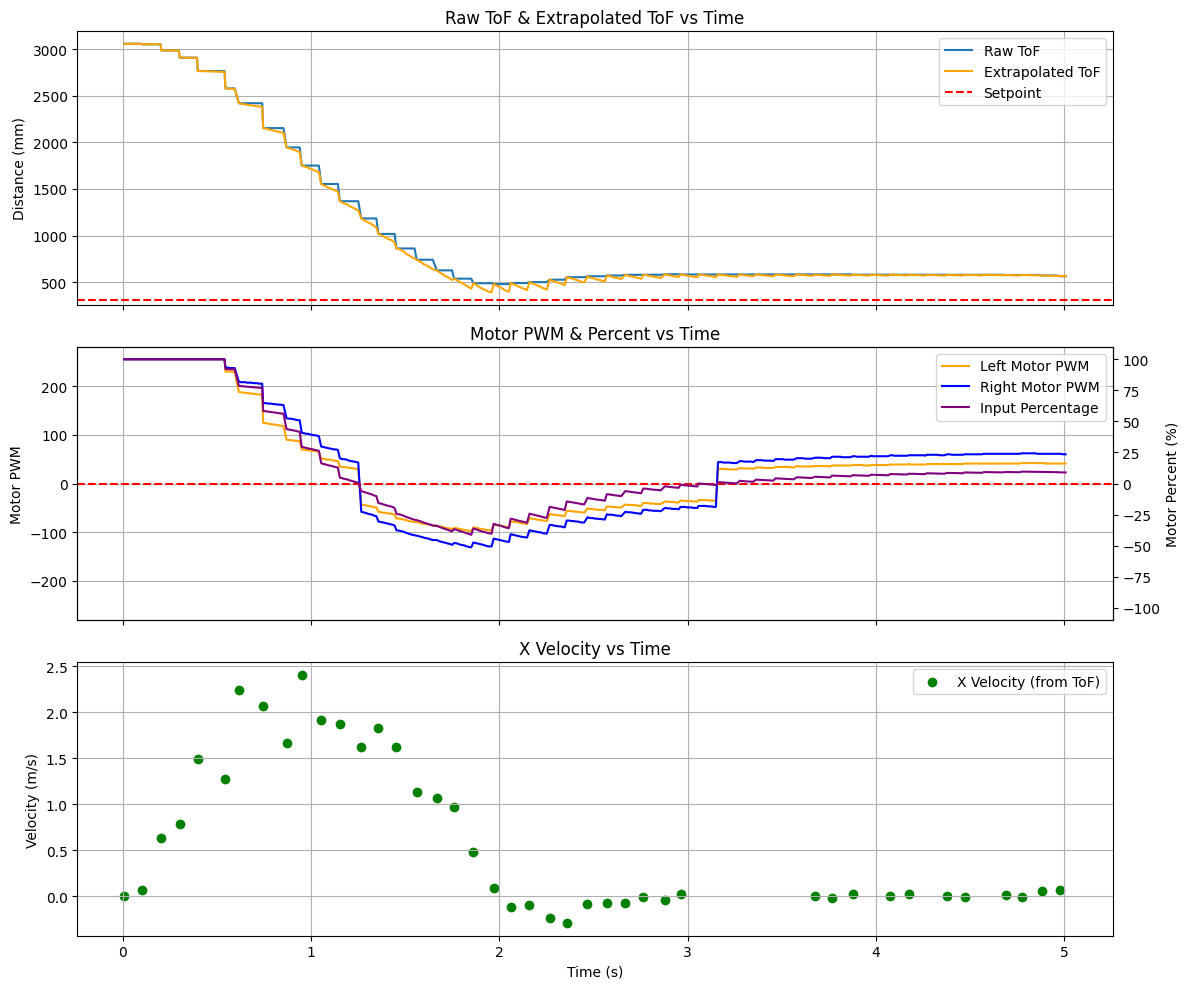

In [1182]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ToF
axes[0].plot(times, tof_2_values, label='Raw ToF')
axes[0].plot(times, sensor_values, label='Extrapolated ToF',  color='orange')
axes[0].axhline(setpoint, linestyle='--', label='Setpoint', color='red')
axes[0].set_ylabel('Distance (mm)')
axes[0].set_title('Raw ToF & Extrapolated ToF vs Time')
axes[0].legend()
axes[0].grid(True)
# axes[0].set_xlim(1, 2)

# Motors
ax_pwm = axes[1]
ax_pct = ax_pwm.twinx()
ax_pwm.plot(times, left_motors, label='Left Motor PWM', color='orange')
ax_pwm.plot(times, right_motors, label='Right Motor PWM', color='blue')
ax_pwm.axhline(0, linestyle='--', color='red')
ax_pwm.set_ylabel('Motor PWM')
ax_pwm.set_title('Motor PWM & Percent vs Time')
ax_pwm.set_ylim(-280.5, 280.5)
ax_pwm.grid(True)
ax_pct.plot(times, left_percent,  label='Input Percentage', linestyle='-', color='purple')
ax_pct.set_ylabel('Motor Percent (%)')
ax_pct.set_ylim(-110, 110)
lines1, labels1 = ax_pwm.get_legend_handles_labels()
lines2, labels2 = ax_pct.get_legend_handles_labels()
ax_pwm.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# X velocity
# axes[2].axhline(v_end, linestyle='--', color='blue', label='Steady-State Speed')
# axes[2].axhline(v90, linestyle='--', color='purple', label='90% Speed')
# axes[2].plot(t_fit, v_fit, label='Fit Line', linestyle='--', color='orange')
axes[2].scatter(times_v, velocities, label='X Velocity (from ToF)',  color='green')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Velocity (m/s)')
axes[2].set_title('X Velocity vs Time')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()